<a href="https://colab.research.google.com/github/Madan-Ram-sai/Digit-Recognition-MNIST/blob/main/Digit_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
drive_path = '/content/drive/MyDrive/digit_rec_imgs/'


Mounted at /content/drive


# Neural Networks

---



In [ ]:
from keras.datasets import mnist
(X_train,y_train),(X_test,y_test) = mnist.load_data()
print(f"Train data : {X_train.shape}, {y_train.shape}")
print(f"Test data : {X_test.shape}, {y_test.shape}")

X_train_reshaped = X_train.reshape((-1,28*28))
X_train_reshaped = X_train_reshaped.astype('float32')/255
X_test_reshaped = X_test.reshape((-1,28*28))
X_test_reshaped = X_test_reshaped.astype('float32')/255

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train data : (60000, 28, 28), (60000,)
Test data : (10000, 28, 28), (10000,)


In [ ]:
%%time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(128,activation='relu',input_shape=(28*28,)),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(X_train_reshaped,y_train,epochs=40,validation_split=0.2)
print(history.history['val_accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9198 - loss: 0.2746 - val_accuracy: 0.9625 - val_loss: 0.1316
Epoch 2/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9655 - loss: 0.1167 - val_accuracy: 0.9673 - val_loss: 0.1067
Epoch 3/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9746 - loss: 0.0812 - val_accuracy: 0.9683 - val_loss: 0.1066
Epoch 4/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9811 - loss: 0.0603 - val_accuracy: 0.9723 - val_loss: 0.0979
Epoch 5/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9848 - loss: 0.0474 - val_accuracy: 0.9723 - val_loss: 0.1016
Epoch 6/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9877 - loss: 0.0384 - val_accuracy: 0.9729 - val_loss: 0.1093
Epoch 7/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9904 - loss: 0.0291 - val_accuracy: 0.9735 - val_loss: 0.1025
Epoch 8/40
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9913 - loss: 0.0256

In [ ]:

y_pred = model.predict(X_train_reshaped).argmax(axis=1)
print(f"Accuracy: {(y_pred == y_train.ravel()).mean():.4f}")

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Accuracy: 0.9931


In [ ]:

y_pred = model.predict(X_test_reshaped).argmax(axis=1)
print(f"Accuracy: {(y_pred == y_test.ravel()).mean():.4f}")

from sklearn.metrics import classification_report
print(classification_report(y_test.ravel(), y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.9761
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.98      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.94      0.98      0.96      1010
           4       0.99      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.99      0.96      0.97      1028
           8       0.95      0.98      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



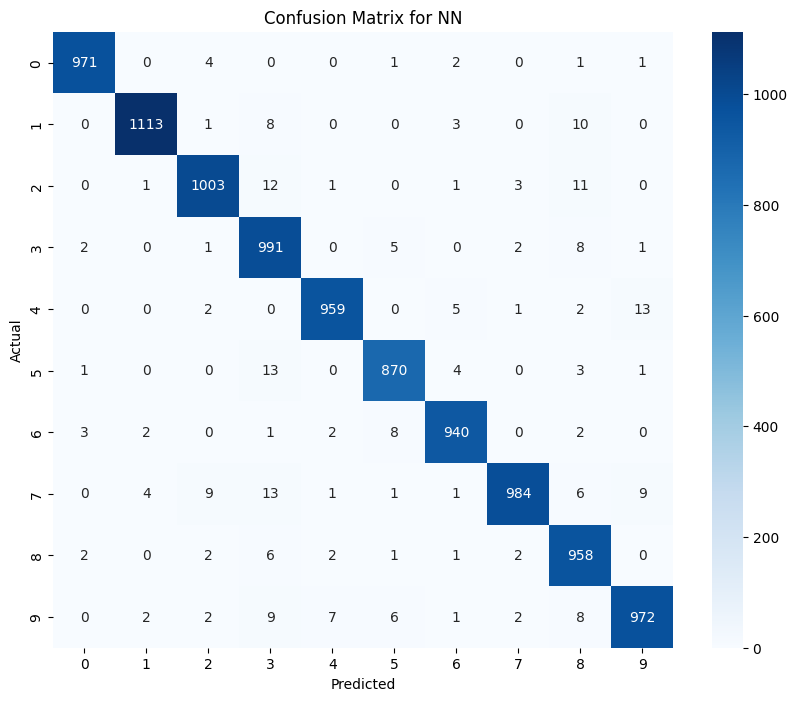

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True,fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for NN")
plt.show()

###ROC()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


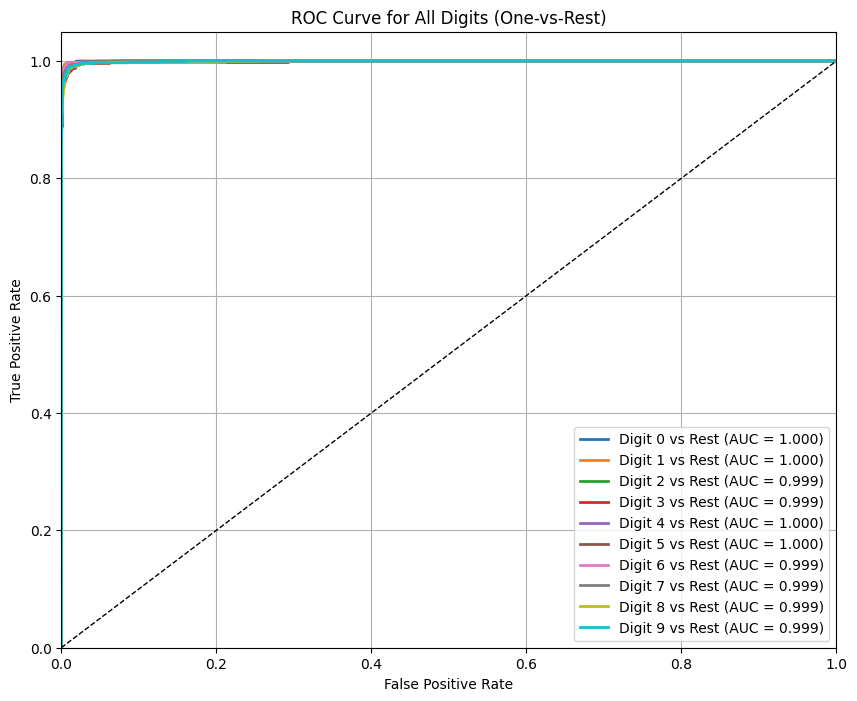

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_score = model.predict(X_test_reshaped)
y_test_bin = label_binarize(y_test, classes=np.arange(10))
plt.figure(figsize=(10,8))

for i in range(10):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"Digit {i} vs Rest (AUC = {roc_auc:.3f})"
    )

plt.plot([0,1], [0,1], 'k--', lw=1)

plt.xlim([0,1])
plt.ylim([0,1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for All Digits (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Predicting some sample digits from images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
probabilities of classifications: [[7.9936041e-19 3.6302215e-18 3.2577885e-09 1.0000000e+00 2.4249377e-25
  9.9791883e-17 6.1142053e-24 1.1146830e-15 3.1851471e-08 1.0582173e-18]]
predicted Digit: 3
Actual Image:


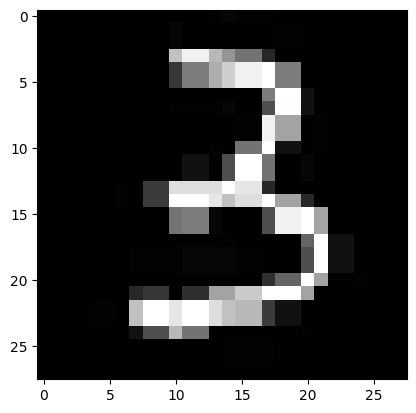

In [ ]:
from tensorflow.keras.preprocessing import image
img_path = os.path.join(drive_path,'testcase.png')
img = image.load_img(img_path, color_mode='grayscale', target_size=(28,28))
img_array = image.img_to_array(img)/255.0
img_array=img_array.reshape(1,28*28)

pred=model.predict(img_array)
print(f"probabilities of classifications: {pred}")
print(f"predicted Digit: {pred.argmax()}")
print(f"Actual Image:")
plt.imshow(img_array.reshape(28,28), cmap='gray')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
probabilities of classifications: [[2.6681926e-14 4.0240571e-09 1.8720429e-12 8.5749664e-11 9.6924551e-02
  3.7221066e-04 6.1132020e-08 5.8359461e-04 9.0196753e-01 1.5204647e-04]]
predicted Digit: 8
Actual Image:


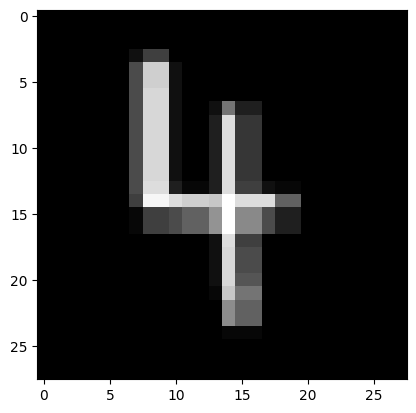

In [ ]:
img_path = os.path.join(drive_path,'testcase2.png')
img = image.load_img(img_path, color_mode='grayscale', target_size=(28,28))
img_array = image.img_to_array(img)/255.0
img_array=img_array.reshape(1,28*28)

pred=model.predict(img_array)
print(f"probabilities of classifications: {pred}")
print(f"predicted Digit: {pred.argmax()}")

print(f"Actual Image:")
plt.imshow(img_array.reshape(28,28), cmap='gray')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
probabilities of classifications: [[3.32177931e-11 9.95489657e-01 3.48854492e-08 1.46529835e-03
  1.96110156e-10 1.01640625e-08 4.79153826e-13 7.03629339e-04
  2.12341617e-03 2.18021276e-04]]
predicted Digit: 1
Actual Image:


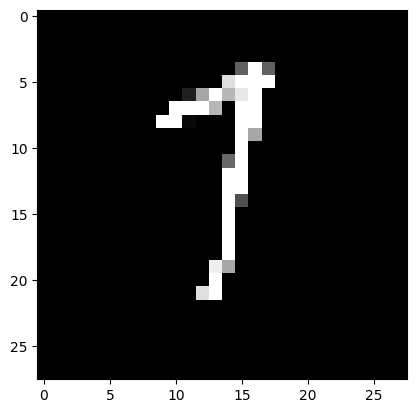

In [ ]:
img_path = os.path.join(drive_path,'testcase5.png')
img = image.load_img(img_path, color_mode='grayscale', target_size=(28,28))
img_array = image.img_to_array(img)/255.0
img_array=img_array.reshape(1,28*28)

pred=model.predict(img_array)
print(f"probabilities of classifications: {pred}")
print(f"predicted Digit: {pred.argmax()}")

print(f"Actual Image:")
plt.imshow(img_array.reshape(28,28), cmap='gray')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
probabilities of classifications: [[1.2970823e-06 6.0480332e-04 4.0788268e-04 3.4406537e-04 1.2466453e-13
  6.7131090e-08 3.6064471e-14 1.3493520e-03 9.9729151e-01 9.9552858e-07]]
predicted Digit: 8
Actual Image:


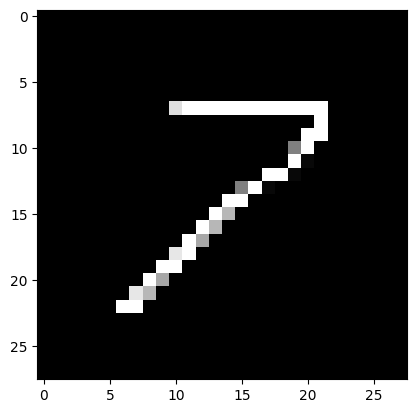

In [ ]:
img_path = os.path.join(drive_path,'Screenshot 2026-04-25 233432.png')
img = image.load_img(img_path, color_mode='grayscale', target_size=(28,28))
img_array = image.img_to_array(img)/255.0
img_array=img_array.reshape(1,28*28)

pred=model.predict(img_array)
print(f"probabilities of classifications: {pred}")
print(f"predicted Digit: {pred.argmax()}")

print(f"Actual Image:")
plt.imshow(img_array.reshape(28,28), cmap='gray')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
probabilities of classifications: [[1.3008494e-19 7.0243176e-09 9.9999988e-01 6.8965967e-08 1.9079596e-22
  1.2808239e-18 6.5270585e-17 1.5230093e-12 1.5614647e-13 4.4353537e-25]]
predicted Digit: 2
Actual Image:


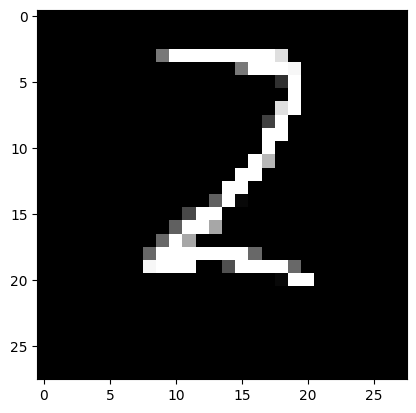

In [ ]:
img_path = os.path.join(drive_path,'Screenshot 2026-04-25 234057.png')
img = image.load_img(img_path, color_mode='grayscale', target_size=(28,28))
img_array = image.img_to_array(img)/255.0
img_array=img_array.reshape(1,28*28)

pred=model.predict(img_array)
print(f"probabilities of classifications: {pred}")
print(f"predicted Digit: {pred.argmax()}")

print(f"Actual Image:")
plt.imshow(img_array.reshape(28,28), cmap='gray')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
probabilities of classifications: [[1.22974945e-14 1.98396882e-10 5.77703702e-15 2.38402293e-08
  6.91908260e-17 1.00000000e+00 1.52138510e-10 1.13535369e-10
  3.63277319e-09 5.42668341e-11]]
predicted Digit: 5
Actual Image:


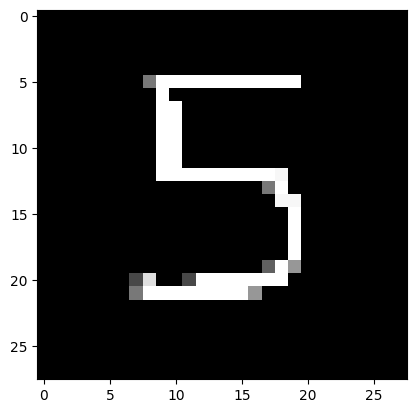

In [ ]:
img_path = os.path.join(drive_path,'Screenshot 2026-04-25 234221.png')
img = image.load_img(img_path, color_mode='grayscale', target_size=(28,28))
img_array = image.img_to_array(img)/255.0
img_array=img_array.reshape(1,28*28)

pred=model.predict(img_array)
print(f"probabilities of classifications: {pred}")
print(f"predicted Digit: {pred.argmax()}")

print(f"Actual Image:")
plt.imshow(img_array.reshape(28,28), cmap='gray')
plt.show()

# With sklearn

---



### Model 1: RandomForestClassifier



#### Building Model

Accuracy: 0.9704
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



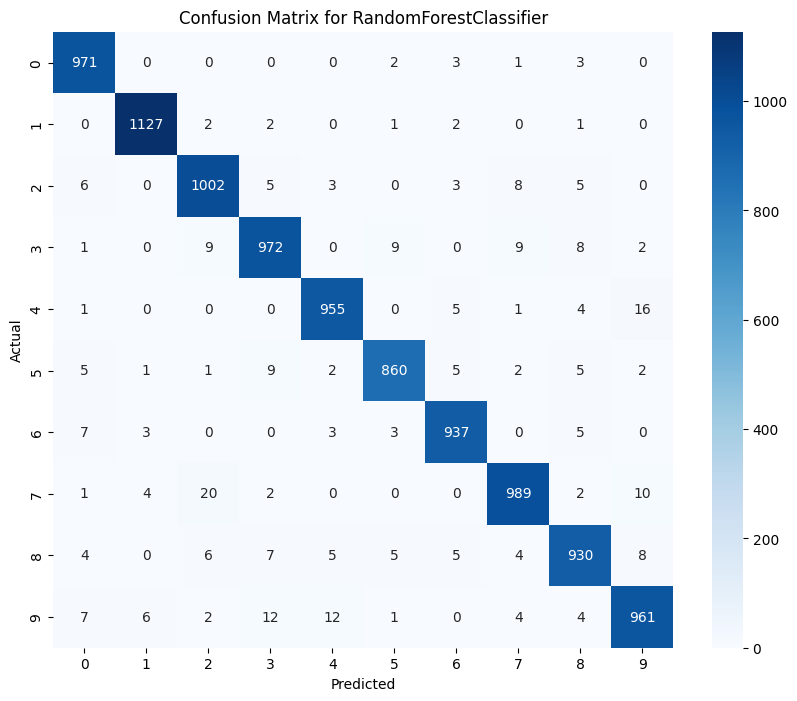

CPU times: user 1min 15s, sys: 193 ms, total: 1min 15s
Wall time: 46.2 s


In [ ]:
%%time
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model1 = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
model1.fit(X_train_reshaped, y_train)

y_pred = model1.predict(X_test_reshaped)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for RandomForestClassifier")
plt.show()

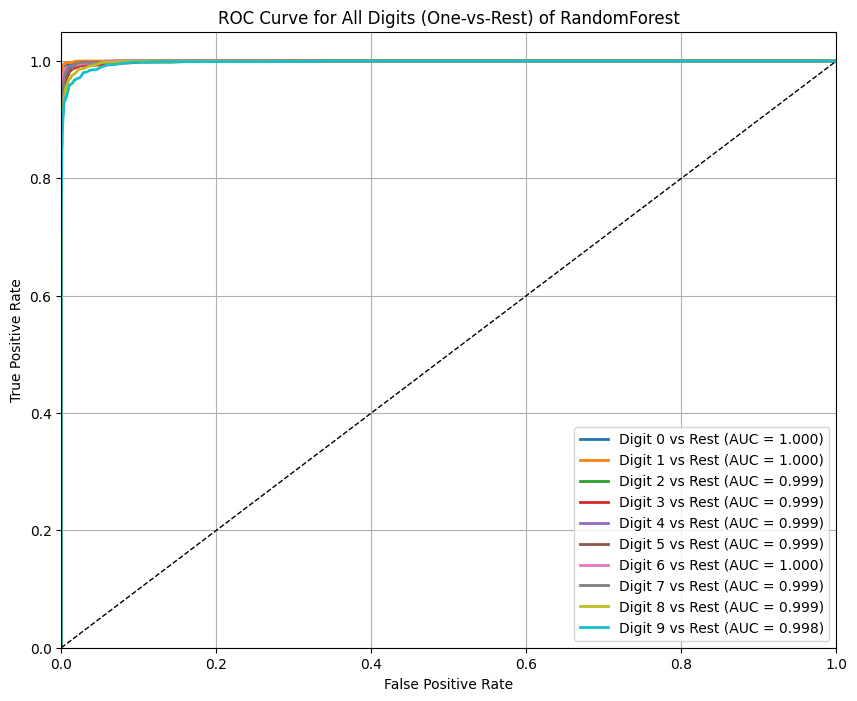

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_score = model1.predict_proba(X_test_reshaped)
y_test_bin = label_binarize(y_test, classes=np.arange(10))
plt.figure(figsize=(10,8))

for i in range(10):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"Digit {i} vs Rest (AUC = {roc_auc:.3f})"
    )

plt.plot([0,1], [0,1], 'k--', lw=1)

plt.xlim([0,1])
plt.ylim([0,1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for All Digits (One-vs-Rest) of RandomForest")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#### Predicting some sample digits from images

predicted Digit: [1]
Actual Image:


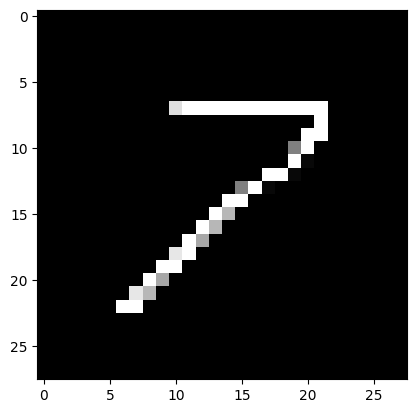

In [ ]:
img_path = os.path.join(drive_path,'Screenshot 2026-04-25 233432.png')
img = image.load_img(img_path, color_mode='grayscale', target_size=(28,28))
img_array = image.img_to_array(img)/255.0
img_array=img_array.reshape(1,28*28)

pred=model1.predict(img_array)
print(f"predicted Digit: {pred}")

print(f"Actual Image:")
plt.imshow(img_array.reshape(28,28), cmap='gray')
plt.show()
#it should predict 7 but it predicted 1 WRONG PREDICTION

predicted Digit: [1]
Actual Image:


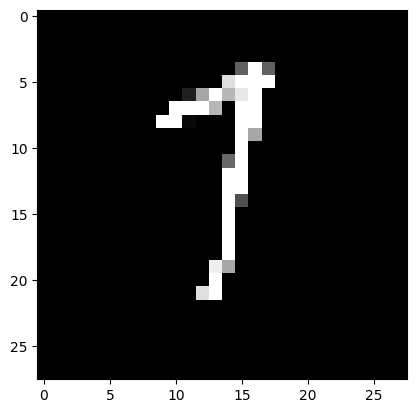

In [ ]:
img_path = os.path.join(drive_path,'testcase5.png')
img = image.load_img(img_path, color_mode='grayscale', target_size=(28,28))
img_array = image.img_to_array(img)/255.0
img_array=img_array.reshape(1,28*28)

pred=model1.predict(img_array)
print(f"predicted Digit: {pred}")

print(f"Actual Image:")
plt.imshow(img_array.reshape(28,28), cmap='gray')
plt.show()

### Model 2: LogesticRegrission

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.926
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.94      0.94       982
           5       0.90      0.87      0.88       892
           6       0.94      0.95      0.95       958
           7       0.93      0.92      0.93      1028
           8       0.88      0.88      0.88       974
           9       0.91      0.92      0.92      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000



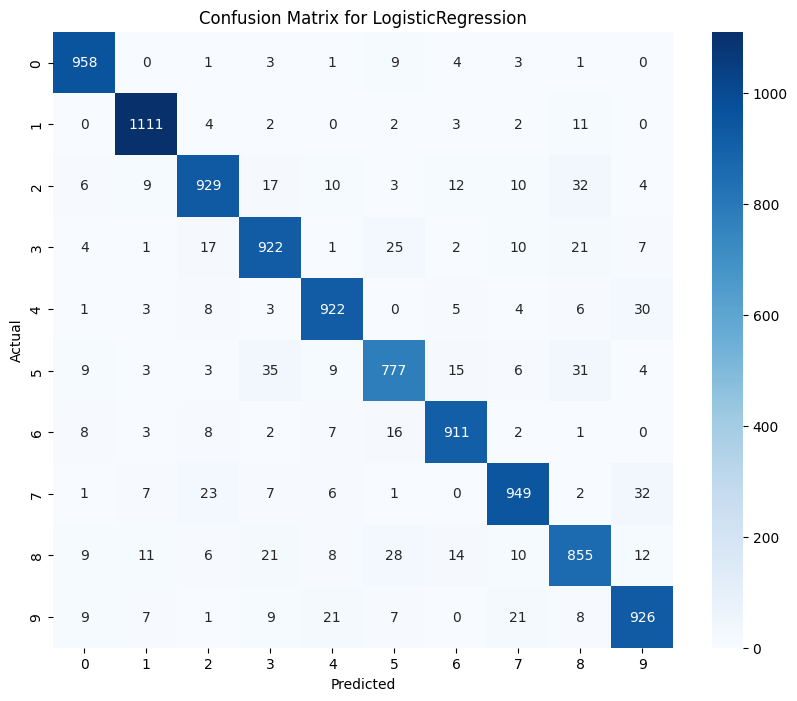

CPU times: user 1.25 s, sys: 530 ms, total: 1.78 s
Wall time: 1min 15s


In [ ]:
%%time
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model2 = LogisticRegression(
    max_iter=1000,
    multi_class='auto',
    n_jobs=-1,
    random_state=42
)

model2.fit(X_train_reshaped, y_train)

y_pred = model2.predict(X_test_reshaped)


acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)


print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for LogisticRegression")
plt.show()

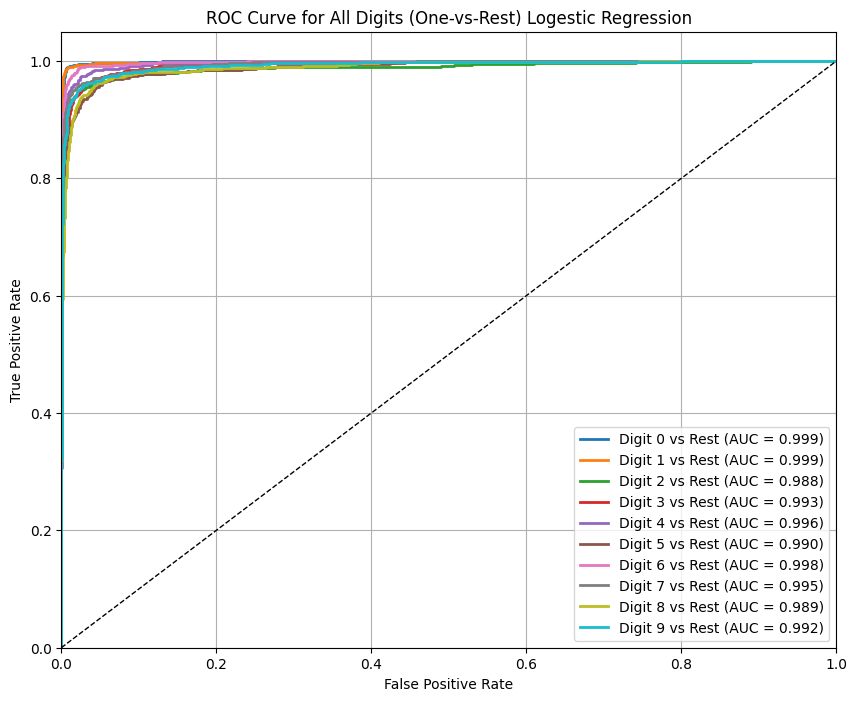

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_score = model2.predict_proba(X_test_reshaped)
y_test_bin = label_binarize(y_test, classes=np.arange(10))
plt.figure(figsize=(10,8))

for i in range(10):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"Digit {i} vs Rest (AUC = {roc_auc:.3f})"
    )

plt.plot([0,1], [0,1], 'k--', lw=1)

plt.xlim([0,1])
plt.ylim([0,1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for All Digits (One-vs-Rest) Logestic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

predicted Digit: [4]
Actual Image:


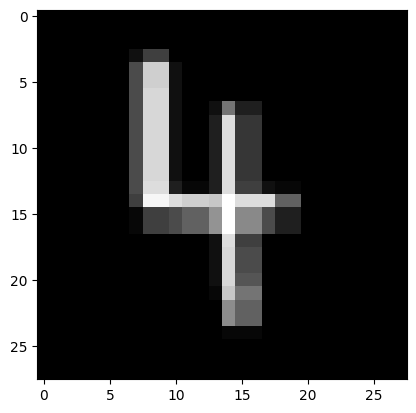

In [ ]:
img_path = os.path.join(drive_path,'testcase2.png')
img = image.load_img(img_path, color_mode='grayscale', target_size=(28,28))
img_array = image.img_to_array(img)/255.0
img_array=img_array.reshape(1,28*28)

pred=model2.predict(img_array)
print(f"predicted Digit: {pred}")

print(f"Actual Image:")
plt.imshow(img_array.reshape(28,28), cmap='gray')
plt.show()

predicted Digit: [5]
Actual Image:


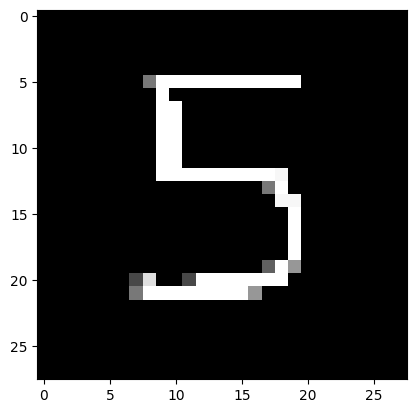

In [ ]:
img_path = os.path.join(drive_path,'Screenshot 2026-04-25 234221.png')
img = image.load_img(img_path, color_mode='grayscale', target_size=(28,28))
img_array = image.img_to_array(img)/255.0
img_array=img_array.reshape(1,28*28)

pred=model2.predict(img_array)
print(f"predicted Digit: {pred}")

print(f"Actual Image:")
plt.imshow(img_array.reshape(28,28), cmap='gray')
plt.show()

### Model 3: SVM

In [ ]:
%%time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
model3 = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

model3.fit(X_train_reshaped, y_train)
y_pred = model3.predict(X_test_reshaped)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9792
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.97      0.99      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.98      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.97      0.97      1028
           8       0.97      0.98      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

CPU times: user 29min 43s, sys: 2.26 s, total: 29min 45s
Wall time: 30min 15s


In [ ]:
y_pred.shape

(10000,)

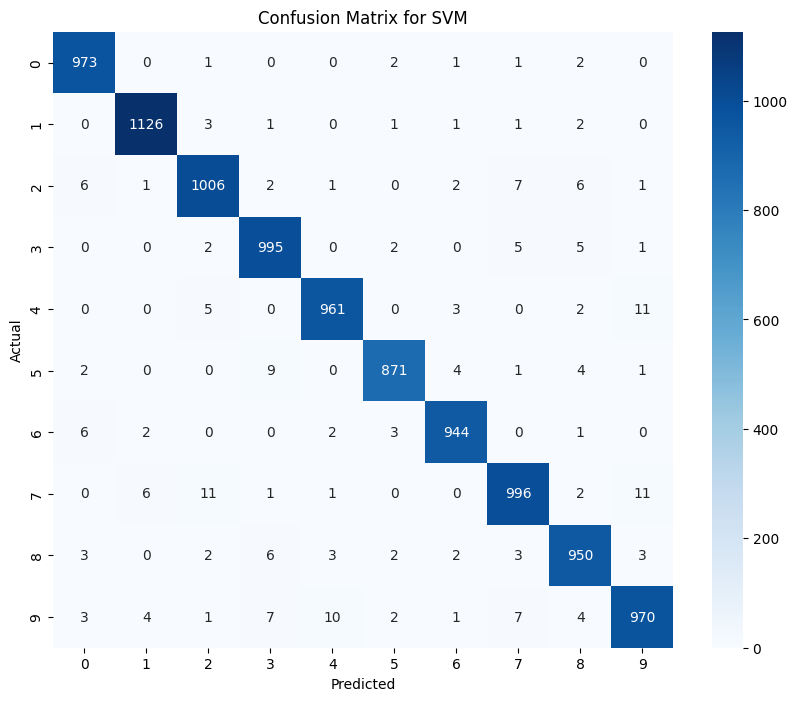

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for SVM")
plt.show()

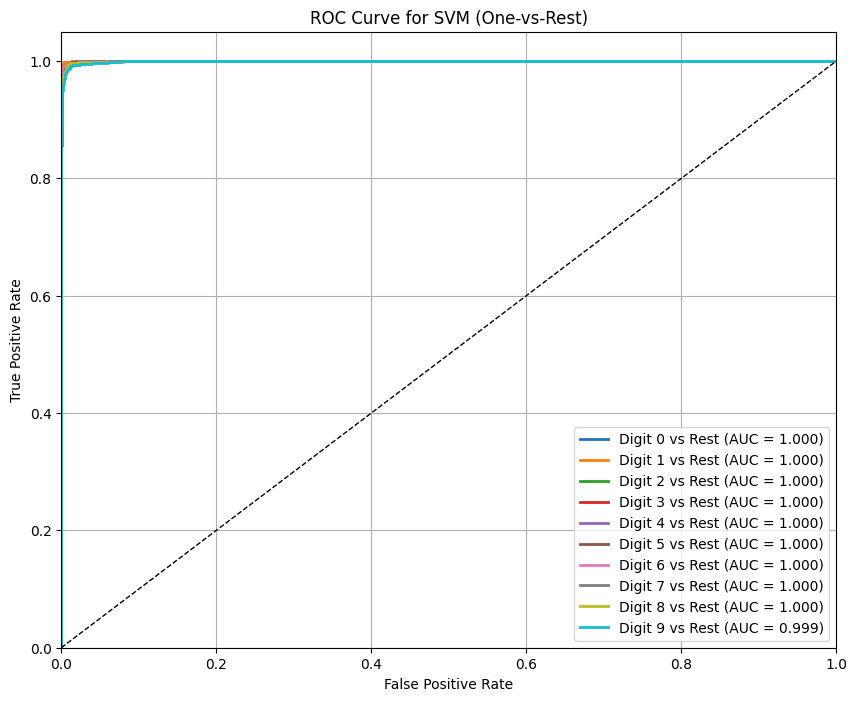

In [ ]:
y_score = model3.predict_proba(X_test_reshaped)

y_test_bin = label_binarize(y_test, classes=np.arange(10))

plt.figure(figsize=(10,8))

for i in range(10):
    fpr, tpr, thresholds = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"Digit {i} vs Rest (AUC = {roc_auc:.3f})"
    )


plt.plot([0,1], [0,1], 'k--', lw=1)

plt.xlim([0,1])
plt.ylim([0,1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for SVM (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()